
#🌀 Modelado Procedural desde Código

El modelado procedural es una técnica en la que las formas, estructuras o superficies se generan mediante algoritmos y reglas matemáticas, en lugar de construirlas manualmente vértice por vértice. Esta forma de modelado permite crear geometrías complejas, repetitivas o dinámicas de manera automática, aprovechando la capacidad del código para producir variaciones infinitas a partir de unos pocos parámetros. En esta práctica se exploran varios ejemplos de generación geométrica por procedimientos: rejillas deformadas, espirales tridimensionales, fractales clásicos y transformaciones aplicadas a mallas, para finalmente compararlas con el modelado tradicional manual.

---

In [8]:

import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (8,6)

### 🔹 Generación de Rejilla

El primer ejercicio muestra cómo se puede construir una superficie tridimensional mediante una rejilla de puntos. En lugar de dibujar manualmente cada vértice, el programa genera una malla de coordenadas distribuidas uniformemente en los ejes X y Y, mientras que la altura (eje Z) se define a partir de una función matemática. Esto permite, por ejemplo, deformar la superficie con ondas senoidales o cualquier otro patrón.
El resultado visual es una cuadrícula tridimensional que puede representar un terreno, una lámina ondulada o una superficie paramétrica. Este ejemplo demuestra cómo un simple conjunto de fórmulas puede dar forma a geometrías suaves y regulares, fácilmente modificables al cambiar algunos parámetros.

---

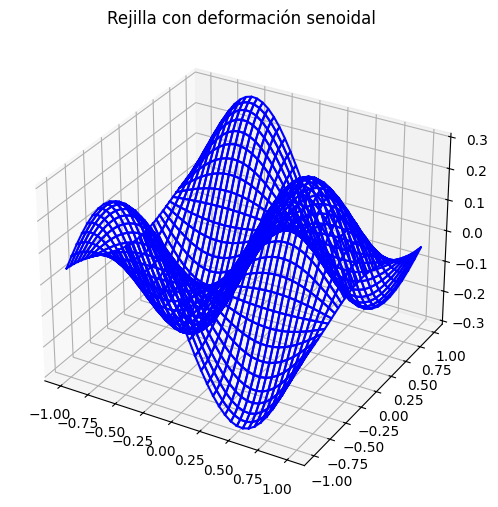

In [9]:
def generate_grid(width=2.0, depth=2.0, nx=20, ny=20, z_func=None):
    xs = np.linspace(-width/2, width/2, nx)
    ys = np.linspace(-depth/2, depth/2, ny)
    verts = []
    for y in ys:
        for x in xs:
            z = 0 if z_func is None else z_func(x, y)
            verts.append([x, y, z])
    verts = np.array(verts)
    faces = []
    for j in range(ny-1):
        for i in range(nx-1):
            a = j*nx + i
            b = a + 1
            c = a + nx + 1
            d = a + nx
            faces.append([a, b, c, d])
    return verts, np.array(faces)

def plot_wireframe(verts, faces, ax=None, color='blue'):
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    for f in faces:
        poly = verts[f.tolist() + [f[0]]]
        ax.plot(poly[:,0], poly[:,1], poly[:,2], color=color)
    return ax

verts, faces = generate_grid(2, 2, 40, 40, z_func=lambda x,y: 0.3*math.sin(3*x)*math.cos(3*y))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plot_wireframe(verts, faces, ax)
ax.set_title("Rejilla con deformación senoidal")
plt.show()




### 🔹 Espiral Archimediana 3D

El segundo ejemplo introduce una espiral tridimensional, una figura que combina crecimiento radial y movimiento ascendente. La espiral se genera incrementando progresivamente el ángulo de rotación y el radio, al tiempo que se eleva la altura, creando un patrón helicoidal.
Este tipo de estructura es común en fenómenos naturales y en diseños arquitectónicos o mecánicos, como resortes o rampas. A través del código, se puede controlar la cantidad de vueltas, la altura y la distancia entre ellas, mostrando el poder del modelado procedural para crear formas precisas y continuas a partir de funciones matemáticas simples.

---

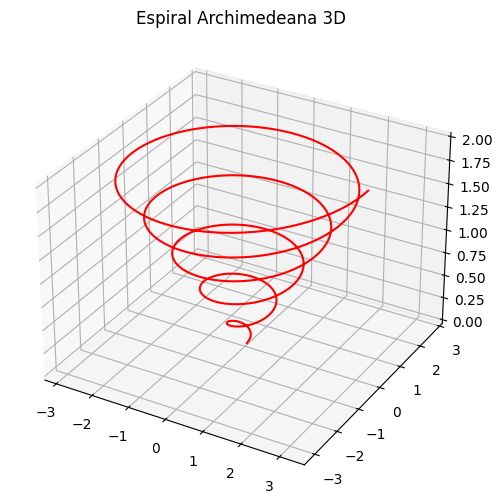

In [10]:
def archimedean_spiral(points=500, turns=5, a=0.05, b=0.1, height=2.0):
    thetas = np.linspace(0, 2*math.pi*turns, points)
    xs = (a + b*thetas) * np.cos(thetas)
    ys = (a + b*thetas) * np.sin(thetas)
    zs = np.linspace(0, height, points)
    return np.column_stack([xs, ys, zs])

spiral = archimedean_spiral()
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(spiral[:,0], spiral[:,1], spiral[:,2], color='red')
ax.set_title("Espiral Archimedeana 3D")
plt.show()


### 🔹 Fractales: Curva de Koch

Este fractal se genera aplicando repetidamente una regla geométrica: cada segmento se reemplaza por una secuencia de cuatro nuevos segmentos que forman un pico triangular.
Con cada nivel de recursión, la figura gana más detalle y complejidad, revelando la auto-similitud característica de los fractales. El resultado es una forma que parece natural, como un copo de nieve o una costa irregular, y demuestra cómo las reglas simples y la recursión pueden crear patrones de gran riqueza visual.

---

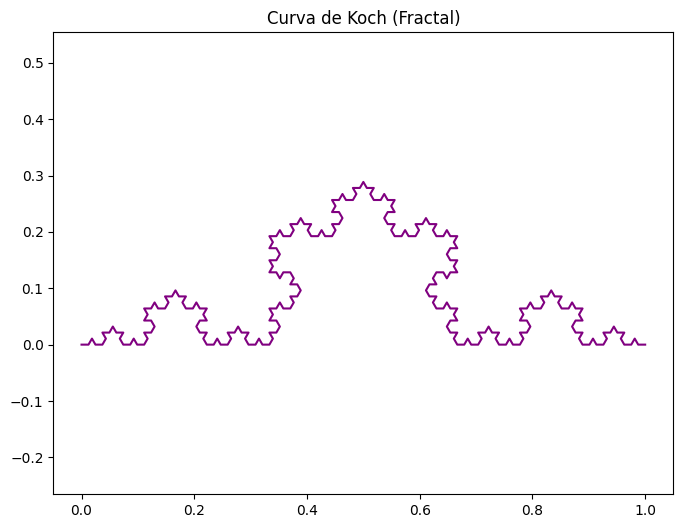

In [11]:
def koch_segment(p1, p2, depth):
    if depth == 0:
        return [p1, p2]
    p1, p2 = np.array(p1), np.array(p2)
    v = p2 - p1
    a = p1 + v/3
    b = p1 + 2*v/3
    angle = math.pi/3
    rot = np.array([[math.cos(angle), -math.sin(angle)], [math.sin(angle), math.cos(angle)]])
    peak = a + rot.dot(b - a)
    segs = []
    segs += koch_segment(p1, a, depth-1)[:-1]
    segs += koch_segment(a, peak, depth-1)[:-1]
    segs += koch_segment(peak, b, depth-1)[:-1]
    segs += koch_segment(b, p2, depth-1)
    return segs

def koch_curve(depth=3):
    return np.array(koch_segment([0,0], [1,0], depth))

pts = koch_curve(4)
plt.plot(pts[:,0], pts[:,1], color='purple')
plt.axis('equal')
plt.title("Curva de Koch (Fractal)")
plt.show()


### 🔹 Triángulo de Sierpinski

El siguiente experimento utiliza un enfoque estocástico (aleatorio) para generar otro fractal: el triángulo de Sierpinski. A partir de un punto inicial dentro de un triángulo, se elige aleatoriamente uno de sus vértices y se marca el punto medio entre ambos, repitiendo el proceso miles de veces.
A pesar de su aparente aleatoriedad, el resultado final muestra una figura perfectamente estructurada, donde los vacíos se organizan en un patrón triangular infinito. Este ejercicio demuestra cómo el azar puede combinarse con reglas deterministas para producir estructuras ordenadas y predecibles.

---

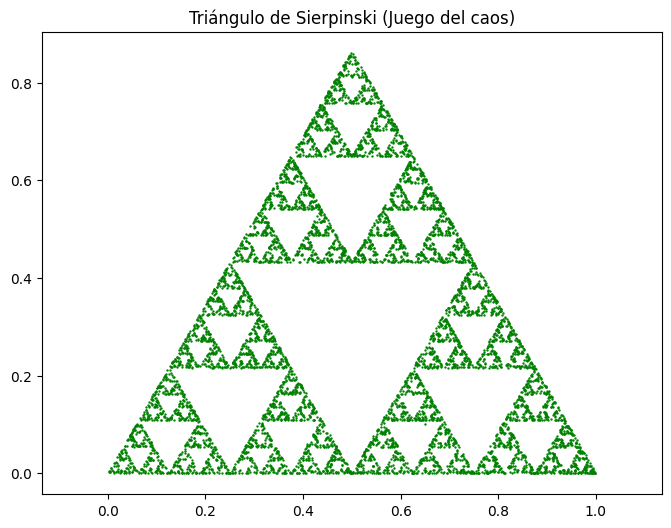

In [12]:
def sierpinski_points(iterations=10000):
    vertices = np.array([[0,0], [1,0], [0.5, math.sqrt(3)/2]])
    p = np.array([0.3, 0.2])
    pts = []
    for _ in range(iterations):
        j = np.random.randint(0, 3)
        p = (p + vertices[j]) / 2
        pts.append(p.copy())
    return np.array(pts)

P = sierpinski_points(8000)
plt.scatter(P[:,0], P[:,1], s=0.5, color='green')
plt.axis('equal')
plt.title("Triángulo de Sierpinski (Juego del caos)")
plt.show()



### 🔹 Transformación Dinámica: “Twist” o Giro

Posteriormente, se aplica una transformación geométrica conocida como *twist*, que consiste en girar progresivamente los vértices de una malla según su distancia al centro. Los puntos más cercanos al eje se mantienen casi fijos, mientras que los más lejanos giran más, generando un efecto de torsión.
Esta transformación ilustra cómo se pueden modificar dinámicamente las geometrías ya creadas, no solo generarlas. Además, permite observar cómo el modelado procedural no se limita a crear formas estáticas, sino que también posibilita deformaciones animadas o paramétricas con facilidad.

---

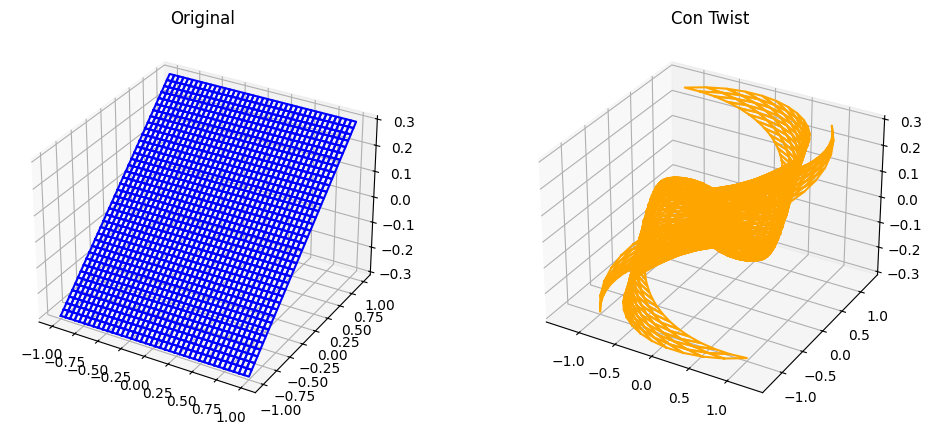

In [13]:
def apply_twist(verts, max_angle=math.pi):
    vs = verts.copy()
    r = np.sqrt(vs[:,0]**2 + vs[:,1]**2)
    thetas = max_angle * (r / (r.max() if r.max()!=0 else 1))
    cs, ss = np.cos(thetas), np.sin(thetas)
    x_new = vs[:,0]*cs - vs[:,1]*ss
    y_new = vs[:,0]*ss + vs[:,1]*cs
    vs[:,0], vs[:,1] = x_new, y_new
    return vs

verts2, faces2 = generate_grid(2, 2, 40, 40, z_func=lambda x,y: 0.3*y)
verts2_twisted = apply_twist(verts2, max_angle=math.pi*2)

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121, projection='3d')
plot_wireframe(verts2, faces2, ax1, color='blue')
ax1.set_title("Original")

ax2 = fig.add_subplot(122, projection='3d')
plot_wireframe(verts2_twisted, faces2, ax2, color='orange')
ax2.set_title("Con Twist")
plt.show()


### 🔹 Comparativa: Modelado Manual vs Modelado Procedural

El modelado manual se basa en crear cada parte del objeto de forma directa, moviendo vértices y caras dentro de un programa 3D. Es un proceso más artístico y visual, ideal cuando se busca un resultado único y detallado, aunque suele ser más lento y menos flexible ante cambios. En cambio, el modelado procedural utiliza algoritmos y código para generar geometría automáticamente. Esto permite crear formas complejas, escalables y repetibles a partir de funciones o parámetros, lo que lo hace mucho más eficiente para entornos grandes, animaciones o simulaciones. Mientras el modelado manual destaca por su control artístico, el procedural sobresale por su precisión, automatización y capacidad de variar modelos con facilidad.
